This notebook discuss how f impact on energy fluxes, especially baroclinic energy flux

In [1]:
%matplotlib inline
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
import scipy.io as sio
import matplotlib
import logging

# import utils as utils
from matplotlib import cm

In [2]:
runname = 'debug_withC_rogers_netcdfBdy1_EB_soliton_withsponge_focus_finey_summer'
datafilepath = '/Volumes/Tan_2024/SUNTANS/NLIW/iwave2024/dongsha/'+runname+'/data_f_1wave/'

# datafilename = 'sun_out.nc_0000.nc'
datafilename = 'sun_sparse.nc_0000.nc'

# path to saved result
resultfilepath = datafilepath+'/results/'
# path to saved figures
outfilepath = '../figure/'
if not os.path.exists(resultfilepath):
    os.mkdir(resultfilepath)
if not os.path.exists(outfilepath):
    os.mkdir(outfilepath)

param_data = {
    "datafilepath": datafilepath,
    "netcdf_filename": datafilename,
            }
param_result = {
    "resultfilepath": resultfilepath,
    "result_filename": 'sun_out_energy_derived.nc',
            }
idx_end = -15

# Read Data

In [3]:
data = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'][:-3]+'_dissp.nc')
data_ = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'])

# Island center & Shoaling depth

In [4]:
lambdaM2=70.1e3
l_sponge = 20e3
L=1.5*lambdaM2+2*l_sponge
W=1.5*lambdaM2

x_c = 2*l_sponge+1.5*lambdaM2/2 
y_c = W/2

In [5]:
depth_top = 4
depth_shoal = 180
depth_bottom = 600-1e-2

# $\int$F'dt

## quiver plot

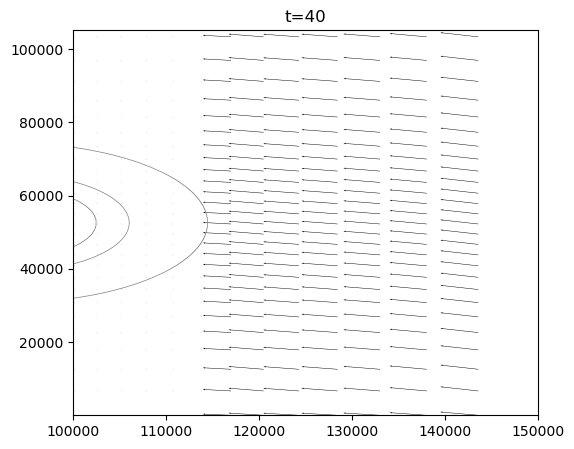

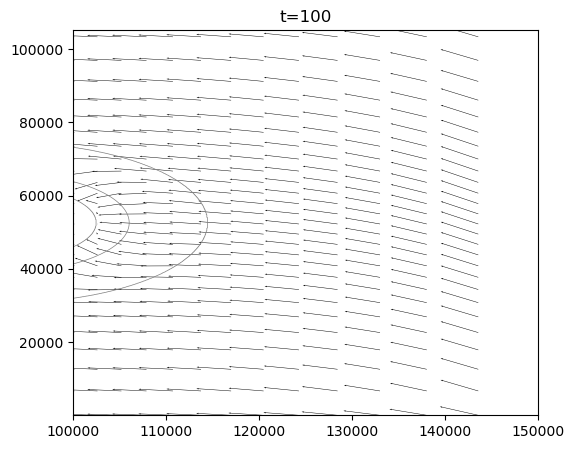

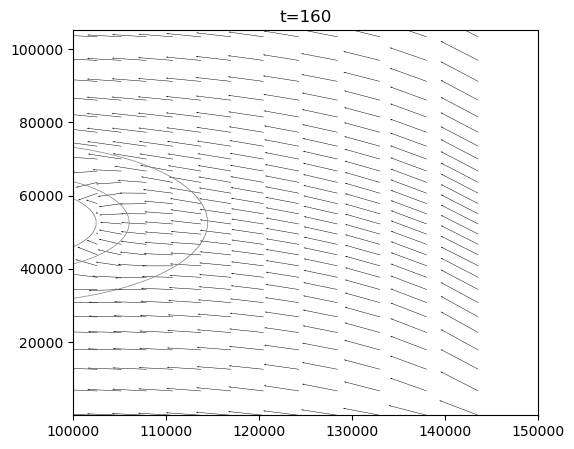

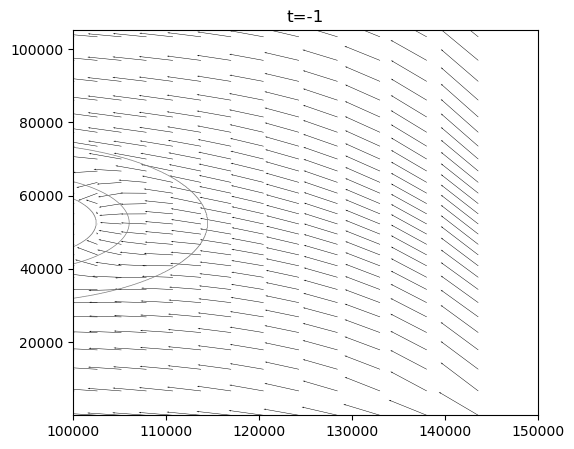

In [6]:
data_bc_fx = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'][:-3]+'_bc_flux_x.nc')
data_bc_fy = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'][:-3]+'_bc_flux_y.nc')

for idx_t in [40,100,160,-1]:
    Fx_prime_int = data_bc_fx.Fx_prime1_int[idx_t,:,:].data+data_bc_fx.Fx_prime2_int[idx_t,:,:].data+data_bc_fx.Fx_prime3_int[idx_t,:,:].data+data_bc_fx.Fx_prime4_int[idx_t,:,:].data+data_bc_fx.Fx_prime5_int[idx_t,:,:].data
    Fy_prime_int = data_bc_fy.Fy_prime1_int[idx_t,:,:].data+data_bc_fy.Fy_prime2_int[idx_t,:,:].data+data_bc_fy.Fy_prime3_int[idx_t,:,:].data+data_bc_fy.Fy_prime4_int[idx_t,:,:].data+data_bc_fy.Fy_prime5_int[idx_t,:,:].data
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,5))
    ax.contour(data.x.data, data.y.data, data_.depth.data.T, levels = [depth_top, depth_shoal, depth_bottom], colors='0.5', linewidths=.5)
    ax.quiver(data.x.data[::50], data.y.data[::50], Fx_prime_int[::50,::50].T, Fy_prime_int[::50,::50].T, scale=1e+8, scale_units='inches', width=1e-3)
    ax.set_xlim([100e3, 150e3])
    ax.set_title(f't={idx_t}')

## time series at x_c+40km

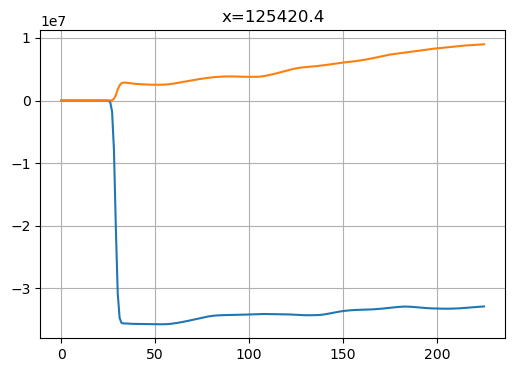

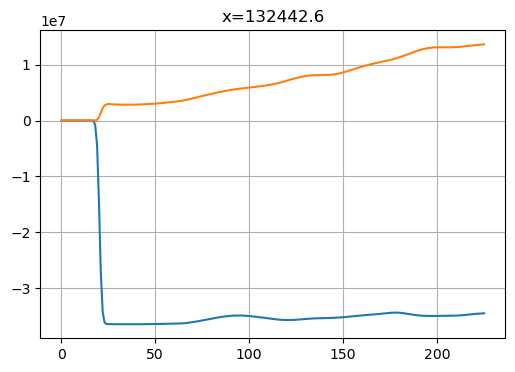

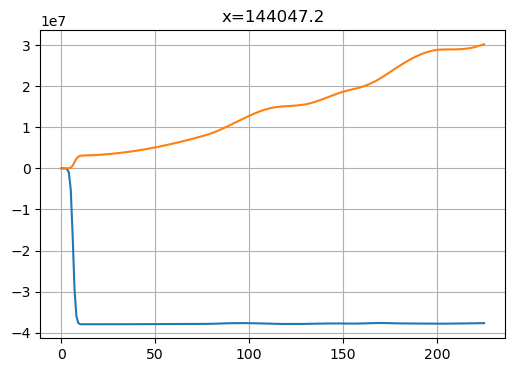

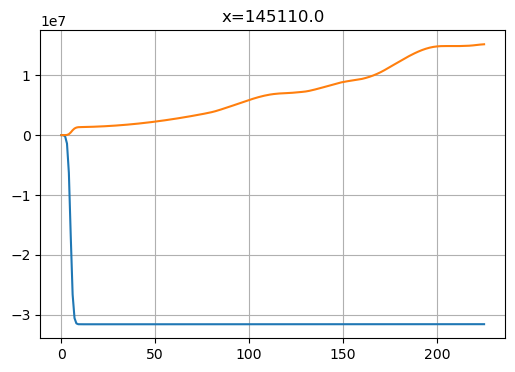

In [7]:
idx_y = 657
for idx_x in [-200,-120,-10,-1]:
    Fx_prime_int = data_bc_fx.Fx_prime1_int[:,idx_x,:].data+data_bc_fx.Fx_prime2_int[:,idx_x,:].data+data_bc_fx.Fx_prime3_int[:,idx_x,:].data+data_bc_fx.Fx_prime4_int[:,idx_x,:].data+data_bc_fx.Fx_prime5_int[:,idx_x,:].data
    Fy_prime_int = data_bc_fy.Fy_prime1_int[:,idx_x,:].data+data_bc_fy.Fy_prime2_int[:,idx_x,:].data+data_bc_fy.Fy_prime3_int[:,idx_x,:].data+data_bc_fy.Fy_prime4_int[:,idx_x,:].data+data_bc_fy.Fy_prime5_int[:,idx_x,:].data
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,4))
    # ax.plot(np.ones(Fx_prime_int[:,idx_y].shape)*((data_bc_fx.time[-1]-data_bc_fx.time[0]).data.astype('int')*1e-9+8))
    ax.plot(Fx_prime_int[:,idx_y])
    ax.plot(Fy_prime_int[:,idx_y])
    ax.set_title(f'x={data.x.data[idx_x]}')
    ax.grid(True)

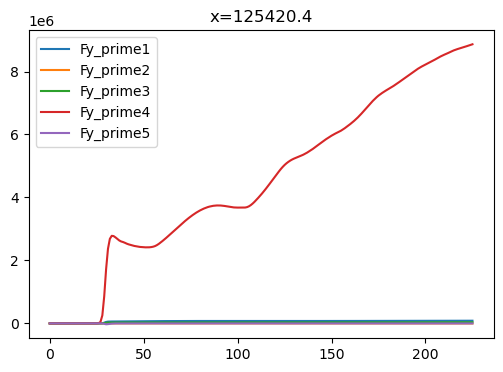

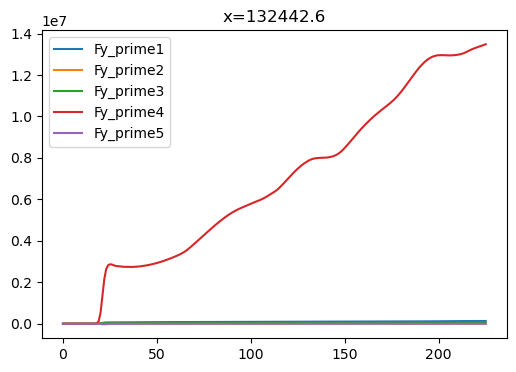

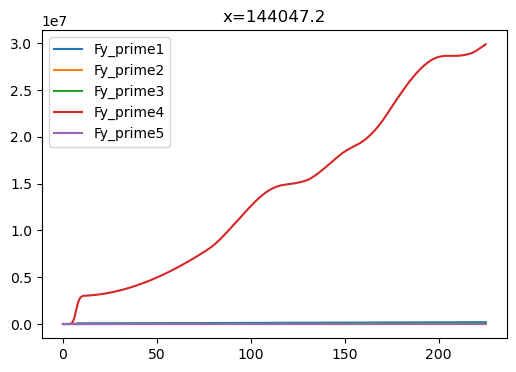

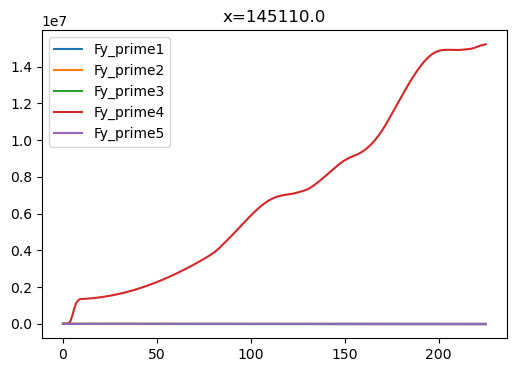

In [8]:
idx_y = 657
for idx_x in [-200,-120,-10,-1]:
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,4))
    ax.plot(data_bc_fy.Fy_prime1_int[:,idx_x,:].data[:,idx_y],label='Fy_prime1')
    ax.plot(data_bc_fy.Fy_prime2_int[:,idx_x,:].data[:,idx_y],label='Fy_prime2')
    ax.plot(data_bc_fy.Fy_prime3_int[:,idx_x,:].data[:,idx_y],label='Fy_prime3')
    ax.plot(data_bc_fy.Fy_prime4_int[:,idx_x,:].data[:,idx_y],label='Fy_prime4')
    ax.plot(data_bc_fy.Fy_prime5_int[:,idx_x,:].data[:,idx_y],label='Fy_prime5')
    ax.set_title(f'x={data.x.data[idx_x]}')
    ax.legend()
    

# F'(t)

In [9]:
data_bc_fx_nof = xr.open_dataset('/Volumes/Tan_2024/SUNTANS/NLIW/iwave2024/dongsha/'+runname+'/data_nof_1wave/results/'+param_result['result_filename'][:-3]+'_bc_flux_x.nc')
data_bc_fy_nof = xr.open_dataset('/Volumes/Tan_2024/SUNTANS/NLIW/iwave2024/dongsha/'+runname+'/data_nof_1wave/results/'+param_result['result_filename'][:-3]+'_bc_flux_y.nc')

In [10]:
Fx_prime_int_f = data_bc_fx.Fx_prime1_int + data_bc_fx.Fx_prime2_int+ data_bc_fx.Fx_prime3_int + data_bc_fx.Fx_prime4_int + data_bc_fx.Fx_prime5_int
Fy_prime_int_f = data_bc_fy.Fy_prime1_int + data_bc_fy.Fy_prime2_int+ data_bc_fy.Fy_prime3_int + data_bc_fy.Fy_prime4_int + data_bc_fy.Fy_prime5_int

Fx_prime_int_nof = data_bc_fx_nof.Fx_prime1_int + data_bc_fx_nof.Fx_prime2_int+ data_bc_fx_nof.Fx_prime3_int + data_bc_fx_nof.Fx_prime4_int + data_bc_fx_nof.Fx_prime5_int
Fy_prime_int_nof = data_bc_fy_nof.Fy_prime1_int + data_bc_fy_nof.Fy_prime2_int+ data_bc_fy_nof.Fy_prime3_int + data_bc_fy_nof.Fy_prime4_int + data_bc_fy_nof.Fy_prime5_int

del data_bc_fx, data_bc_fy, data_bc_fx_nof, data_bc_fy_nof

In [14]:
Fx_prime_f  = Fx_prime_int_f.differentiate("time",datetime_unit="s").data
Fy_prime_f  = Fy_prime_int_f.differentiate("time",datetime_unit="s").data

del Fx_prime_int_f, Fy_prime_int_f

In [15]:
Fx_prime_nof  = Fx_prime_int_nof.differentiate("time",datetime_unit="s").data
Fy_prime_nof  = Fy_prime_int_nof.differentiate("time",datetime_unit="s").data

del Fx_prime_int_nof, Fy_prime_int_nof

/var/folders/sr/6_bkfhj929364hv72k5pf2jw0000gn/T/ipykernel_82695/1011903601.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,4))


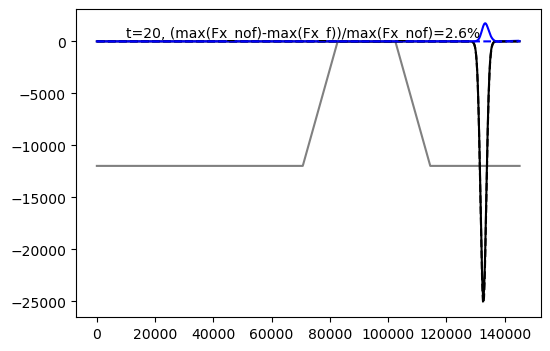

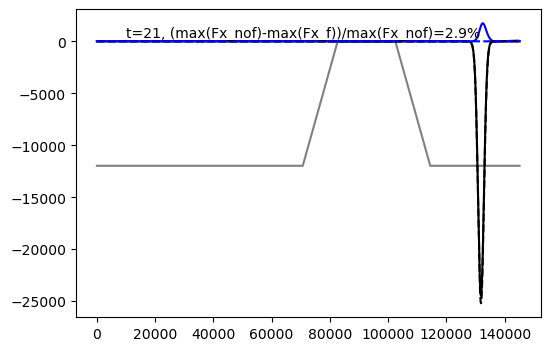

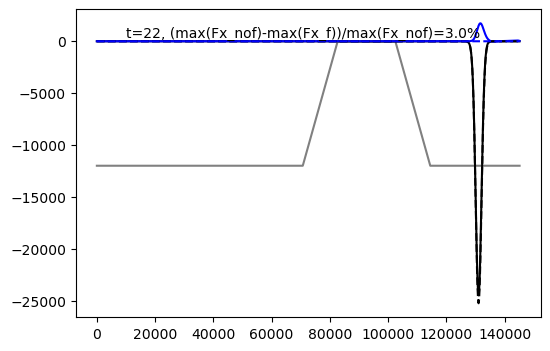

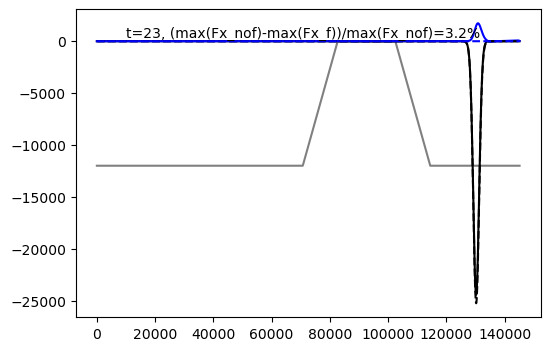

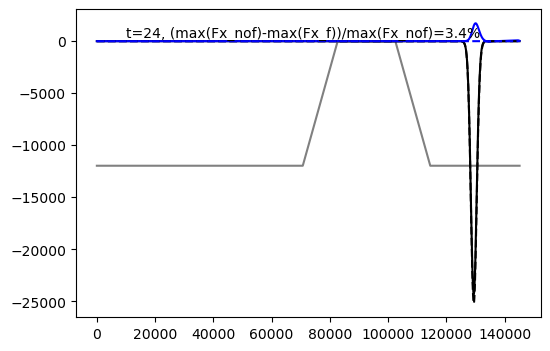

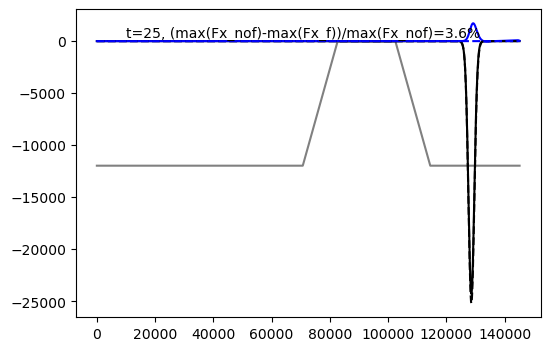

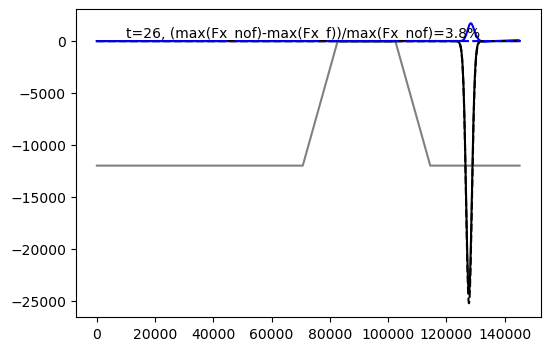

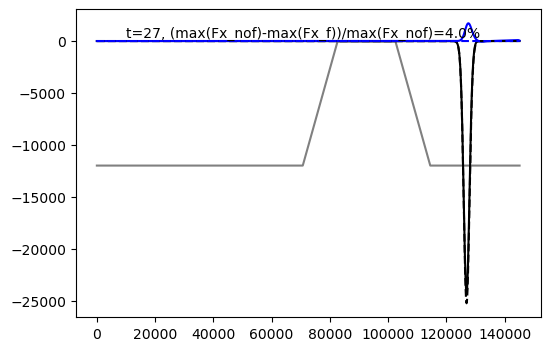

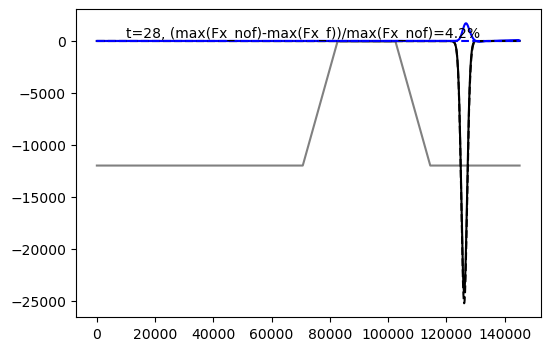

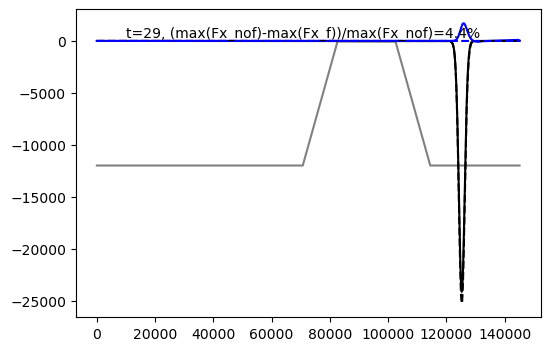

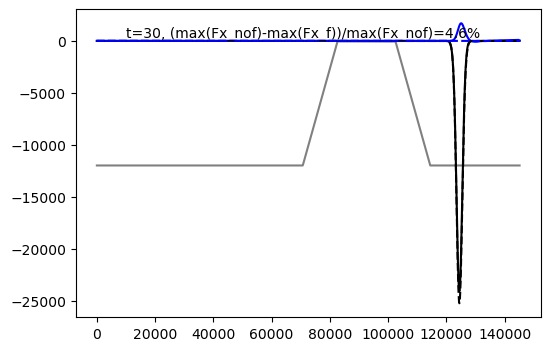

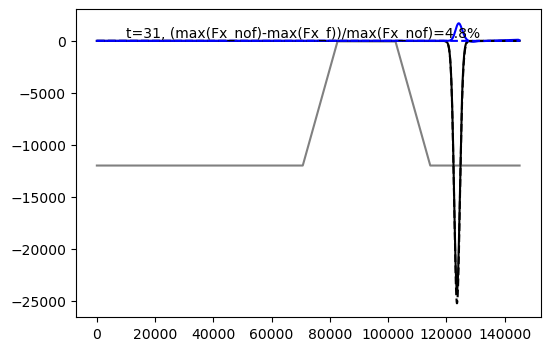

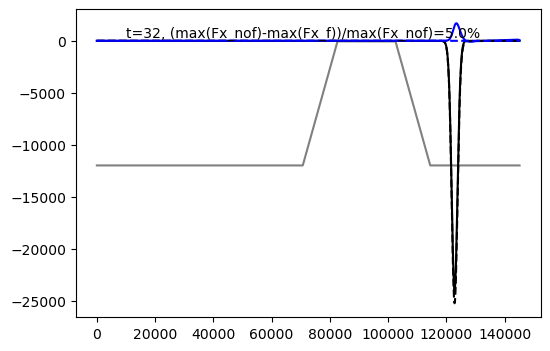

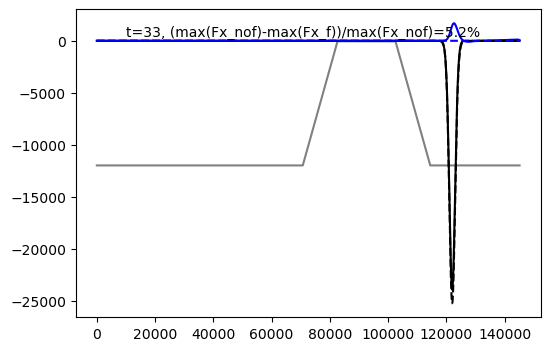

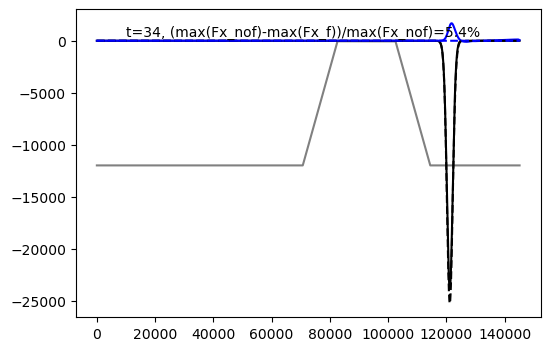

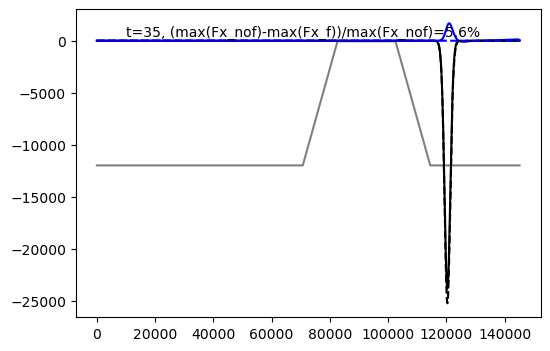

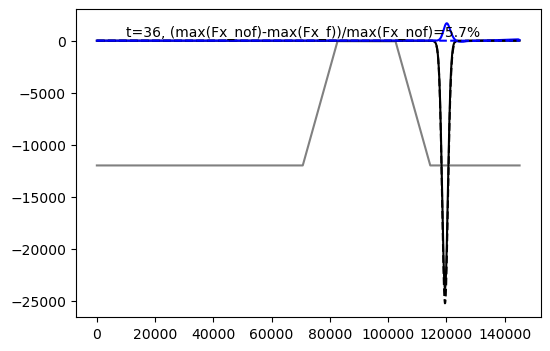

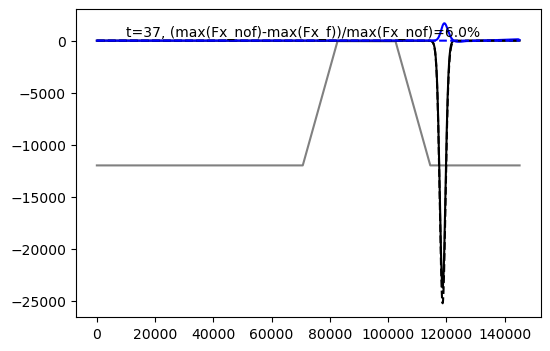

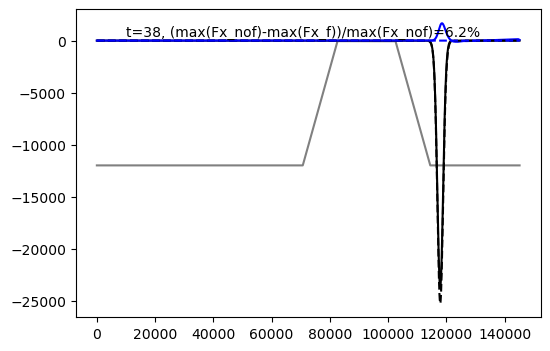

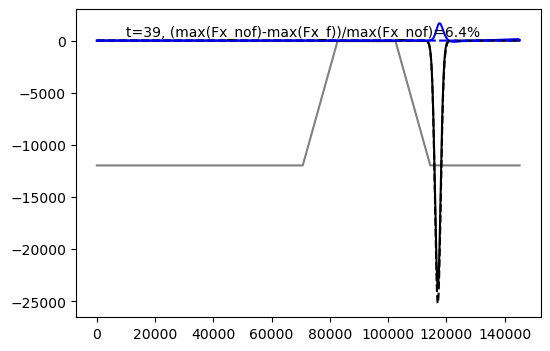

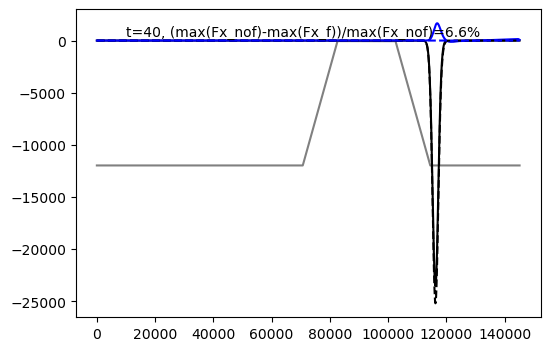

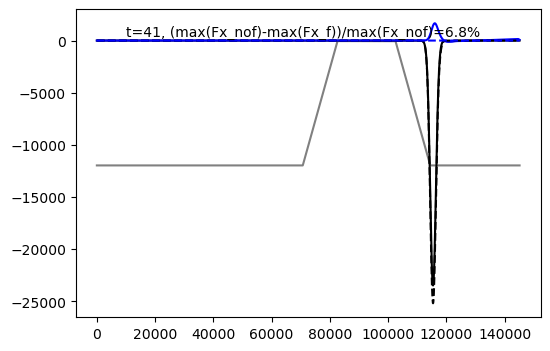

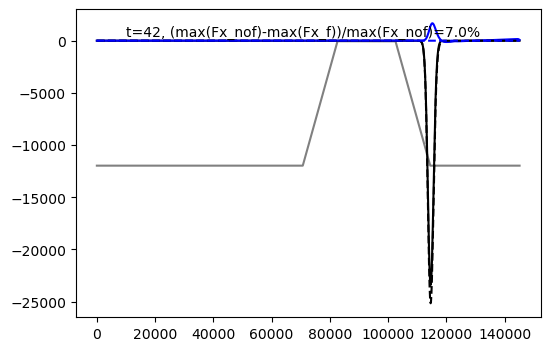

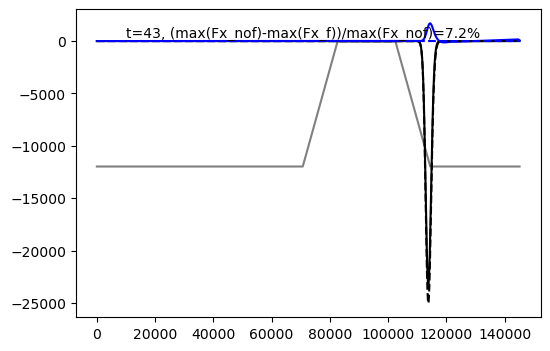

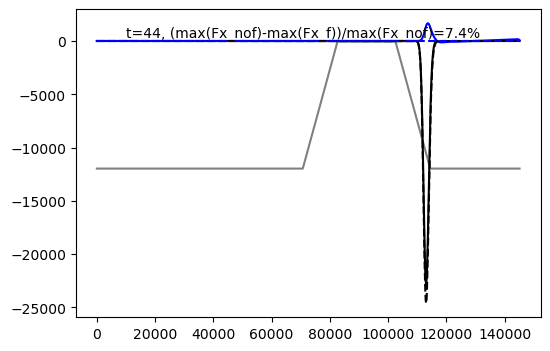

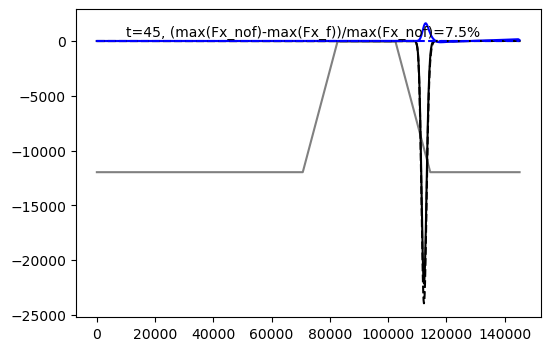

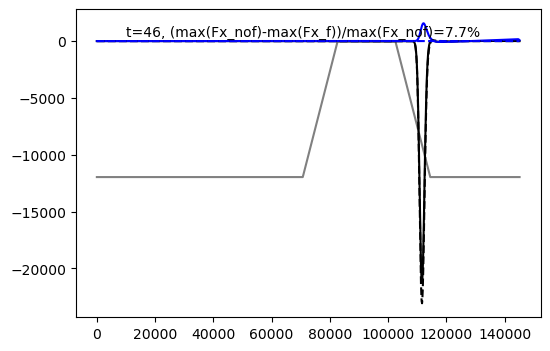

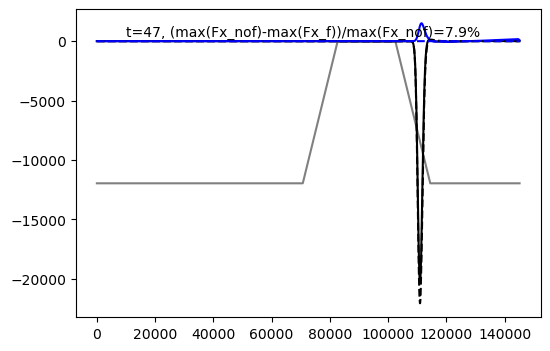

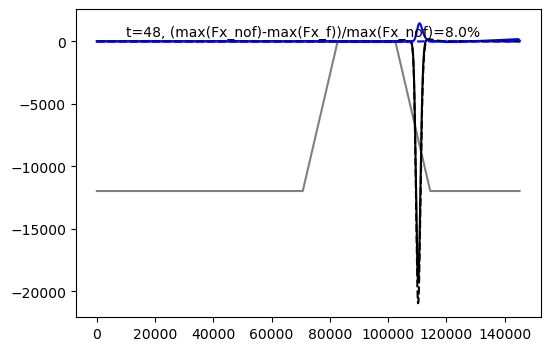

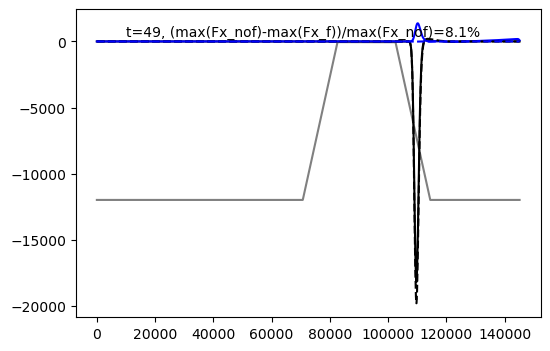

In [17]:
for ind_t in np.arange(20,50,1):
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,4))
    ax.plot(data.x.data, 30-data_.depth[:,idx_y]*20, c='0.5')
    ax.plot(data.x.data,Fx_prime_f[ind_t,:,idx_y], 'k')
    ax.plot(data.x.data,Fy_prime_f[ind_t,:,idx_y], 'b')
    ax.plot(data.x.data,Fx_prime_nof[ind_t,:,idx_y], 'k--')
    ax.plot(data.x.data,Fy_prime_nof[ind_t,:,idx_y], 'b--')
    ratio = (np.max(np.abs(Fx_prime_nof[ind_t,:,idx_y]))-np.max(np.abs(Fx_prime_f[ind_t,:,idx_y])))/np.max(np.abs(Fx_prime_nof[ind_t,:,idx_y]))
    ax.text(1e4, 400, f't={ind_t}, (max(Fx_nof)-max(Fx_f))/max(Fx_nof)={np.round(ratio*1000)/10}%')


In [72]:
dt = (data.time.data-data.time[0].data).astype('int')*1e-9
c = 1.715370234806147
L_w = 6.387548003396961e+03/2

T_scale = L_w*2/c
t_nondim = dt/T_scale

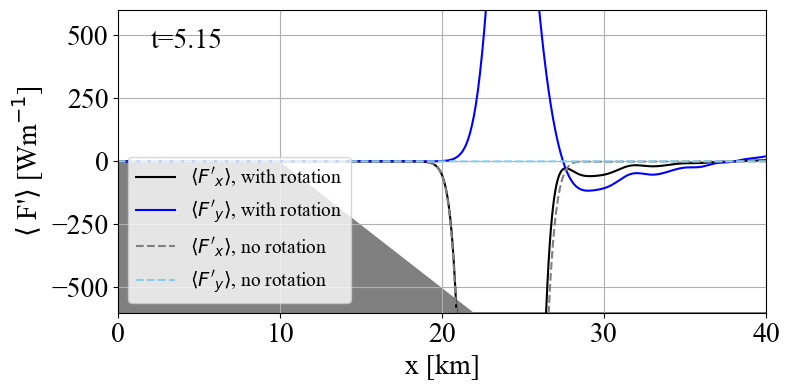

In [82]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8,4))
ind_t = 40
# ax.plot(data.x.data, 30-data_.depth[:,idx_y]/20, c='0.5')
ax.plot(data.x.data,Fx_prime_f[ind_t,:,idx_y], 'k', label=r"$\langle F'_x\rangle$, with rotation")
ax.plot(data.x.data,Fy_prime_f[ind_t,:,idx_y], 'b', label=r"$\langle F'_y\rangle$, with rotation")
ax.plot(data.x.data,Fx_prime_nof[ind_t,:,idx_y], '--', c='gray', label=r"$\langle F'_x\rangle$, no rotation")
ax.plot(data.x.data,Fy_prime_nof[ind_t,:,idx_y], '--', c='skyblue', label=r"$\langle F'_y\rangle$, no rotation")

ax.fill_between(data.x.data, -data_.depth[:,idx_y].data, np.zeros(data.x.data.shape)-600, color='.5')

ax.set_ylim([-600,600])
ax.set_xlim([x_c, x_c+40000])
ax.set_xticks(np.arange(x_c,x_c+40000+1,10000))
ax.set_xticklabels(['0', '10', '20','30', '40'])
ax.set_ylabel(r"$\langle$ F'$\rangle$ [Wm$^{-1}$]", fontsize=20)
ax.set_xlabel('x [km]', fontsize=20)
# ax.set_ylabel('')
ax.set_title(f'')
ax.legend(loc="lower left", fontsize=14)
ax.grid(True)
ax.tick_params(axis='both', which='major', labelsize=20)
plt.rcParams["font.family"] = "Times New Roman"
ax.text(x_c+2e3, 450, f"t={np.round(t_nondim[ind_t]*100)/100}", fontsize=20)
plt.tight_layout()

plt.savefig(outfilepath+ f"F_prim_t{ind_t}_no_with_f.png", transparent = True, dpi=300)